In [6]:
pip install prophet


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: prophet in C:\Users\nikhi\anaconda3\anaconda\Lib\site-packages (1.3.0)



In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [9]:
df = pd.read_csv(r"C:\Users\nikhi\OneDrive\Desktop\coding\engiwo 1\Sales-Forecasting-Demand-Prediction\data\train.csv")


df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [10]:
print(df.shape)

df.info()

df.isnull().sum()

(9800, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dt

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [13]:
sales_daily = df.groupby('Order Date')['Sales'].sum().reset_index()

sales_daily.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


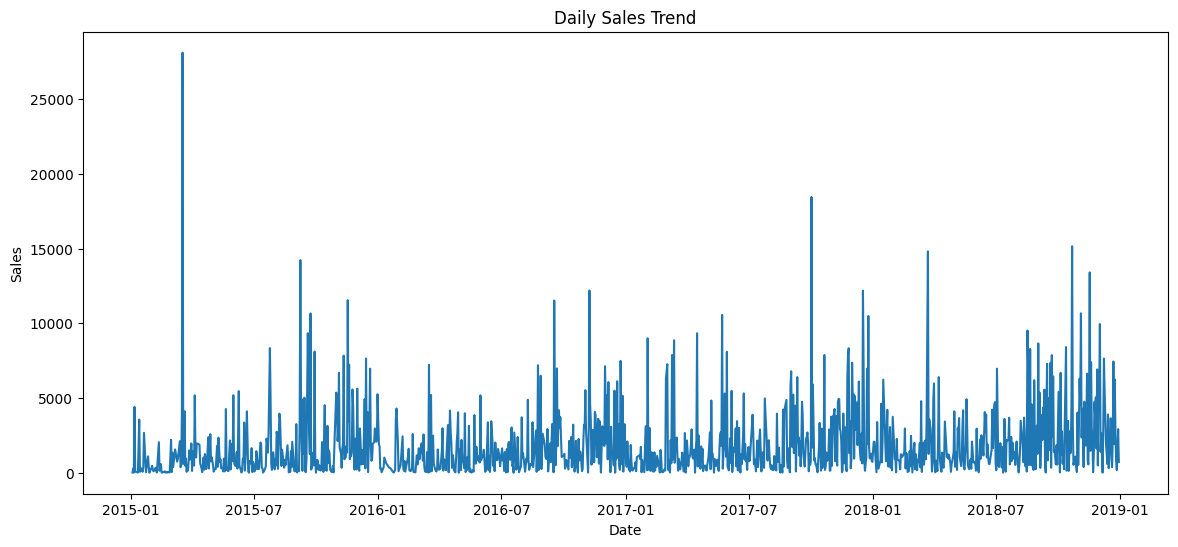

In [14]:
plt.figure(figsize=(14,6))

plt.plot(
    sales_daily['Order Date'],
    sales_daily['Sales']
)

plt.title("Daily Sales Trend")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

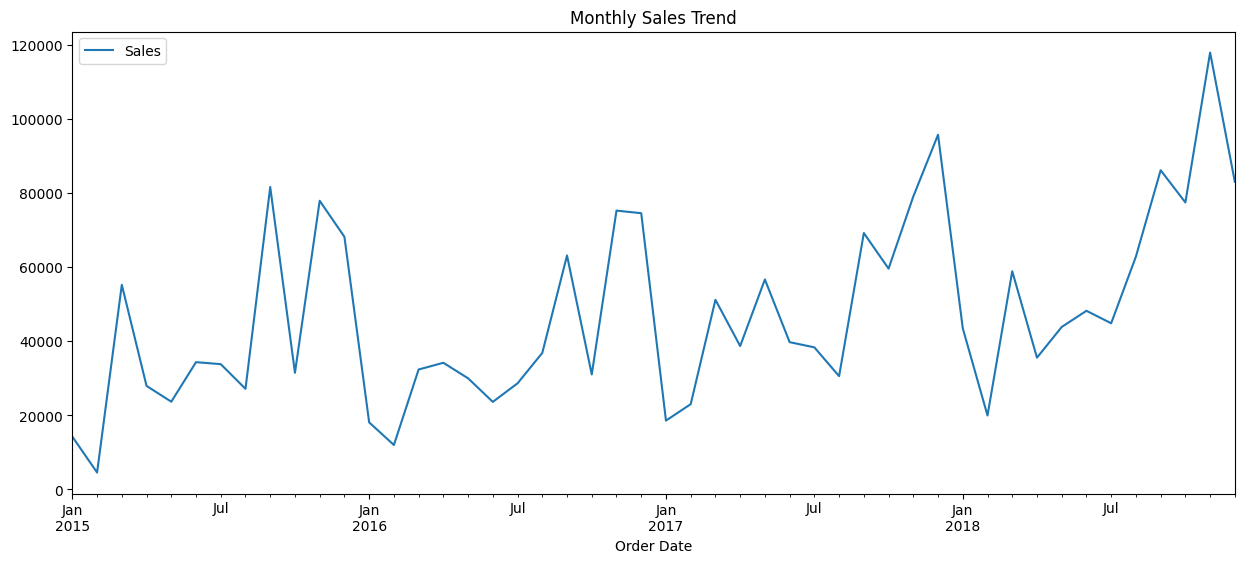

In [15]:
monthly_sales = sales_daily.copy()

monthly_sales.set_index('Order Date', inplace=True)

monthly_sales = monthly_sales.resample('M').sum()

monthly_sales.plot(
    figsize=(15,6)
)

plt.title("Monthly Sales Trend")

plt.show()

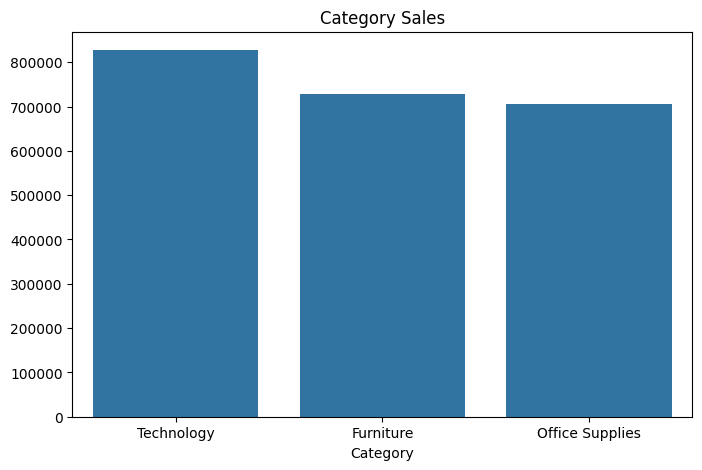

In [16]:
category_sales = df.groupby(
    'Category'
)['Sales'].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Category Sales")

plt.show()

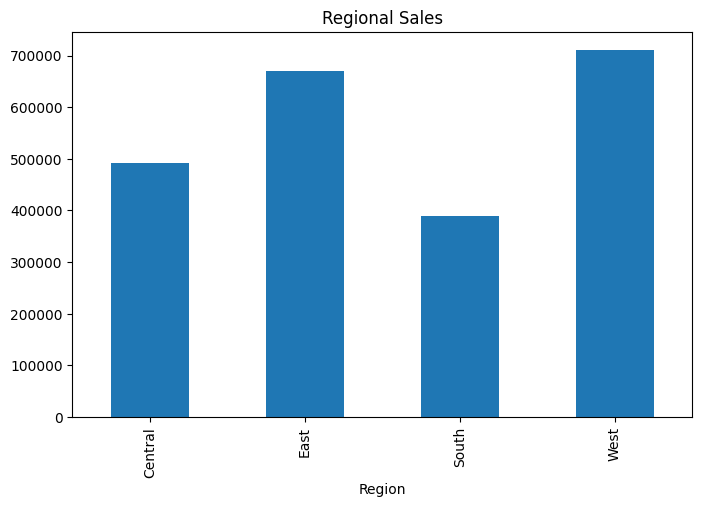

In [17]:
region_sales = df.groupby(
    'Region'
)['Sales'].sum()

plt.figure(figsize=(8,5))

region_sales.plot(
    kind='bar'
)

plt.title("Regional Sales")

plt.show()

In [18]:
prophet_df = sales_daily.rename(
    columns={
        'Order Date':'ds',
        'Sales':'y'
    }
)

In [19]:
train = prophet_df[:-90]

test = prophet_df[-90:]

In [20]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(train)

14:14:33 - cmdstanpy - INFO - Chain [1] start processing
14:14:33 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
future = model.make_future_dataframe(
    periods=90
)

forecast = model.predict(future)


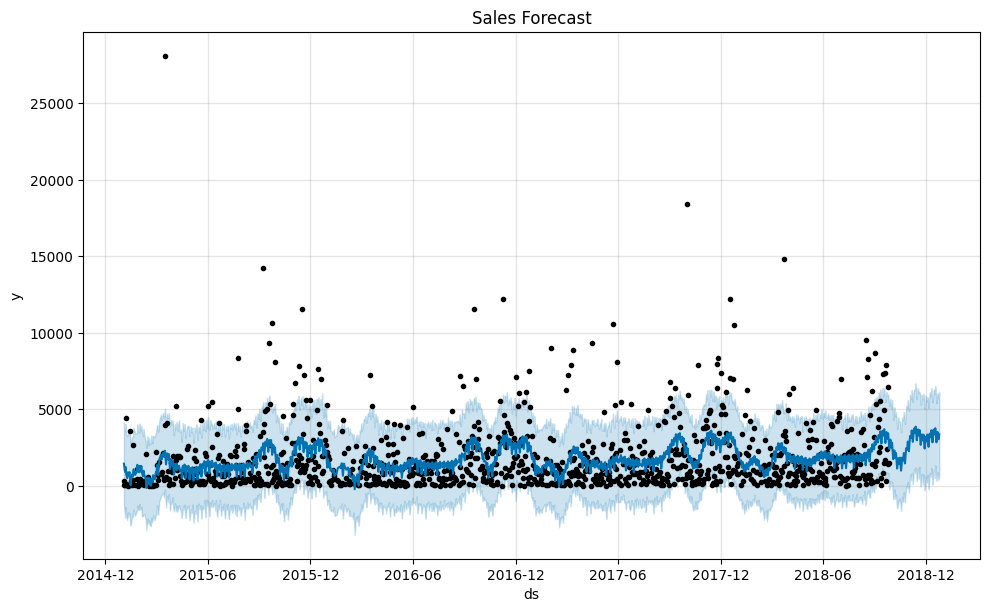

In [22]:
fig = model.plot(forecast)
plt.title("Sales Forecast")
plt.show()

In [23]:
forecast_test = forecast[['ds','yhat']].tail(90)

actual = test['y'].values

predicted = forecast_test['yhat'].values

In [24]:
mae = mean_absolute_error(
    actual,
    predicted
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

mape = np.mean(
    np.abs(
        (actual-predicted)/actual
    )
)*100

print("MAE:",mae)

print("RMSE:",rmse)

print("MAPE:",mape)

MAE: 2212.876677553685
RMSE: 3069.4982970791098
MAPE: 756.5786079065648


In [25]:
future_60 = model.make_future_dataframe(
    periods=60
)

forecast_60 = model.predict(
    future_60
)

forecast_60.tail(60)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1140,2018-09-27,2092.855307,-229.989710,5048.371328,2092.855307,2092.855307,317.474551,317.474551,317.474551,-508.408810,-508.408810,-508.408810,825.883361,825.883361,825.883361,0.0,0.0,0.0,2410.329858
1141,2018-09-28,2093.524694,136.185381,5372.404597,2093.524694,2093.524694,583.732811,583.732811,583.732811,-156.400967,-156.400967,-156.400967,740.133778,740.133778,740.133778,0.0,0.0,0.0,2677.257505
1142,2018-09-29,2094.194081,360.997588,5650.847976,2094.194081,2094.194081,918.309839,918.309839,918.309839,269.516131,269.516131,269.516131,648.793709,648.793709,648.793709,0.0,0.0,0.0,3012.503921
1143,2018-09-30,2094.863468,288.824340,5664.597883,2094.863468,2094.863468,670.202596,670.202596,670.202596,117.402683,117.402683,117.402683,552.799914,552.799914,552.799914,0.0,0.0,0.0,2765.066064
1144,2018-10-01,2095.532855,-185.562485,5226.795239,2095.532855,2095.532855,401.244138,401.244138,401.244138,-51.944304,-51.944304,-51.944304,453.188442,453.188442,453.188442,0.0,0.0,0.0,2496.776994
1145,2018-10-02,2096.202243,96.932024,5442.611392,2096.202243,2096.202243,711.444938,711.444938,711.444938,360.360905,360.360905,360.360905,351.084033,351.084033,351.084033,0.0,0.0,0.0,2807.647181
1146,2018-10-03,2096.871630,-250.449992,5042.282517,2096.871630,2096.871630,217.161800,217.161800,217.161800,-30.525637,-30.525637,-30.525637,247.687437,247.687437,247.687437,0.0,0.0,0.0,2314.033430
1147,2018-10-04,2097.541017,-1007.808012,4435.828469,2097.541017,2097.541017,-364.148040,-364.148040,-364.148040,-508.408810,-508.408810,-508.408810,144.260770,144.260770,144.260770,0.0,0.0,0.0,1733.392976
1148,2018-10-05,2098.210404,-691.952544,4589.731733,2098.210404,2098.210404,-114.289913,-114.289913,-114.289913,-156.400967,-156.400967,-156.400967,42.111054,42.111054,42.111054,0.0,0.0,0.0,1983.920491
1149,2018-10-06,2098.879791,-110.037570,4939.168770,2098.879791,2098.879791,212.088274,212.088274,212.088274,269.516131,269.516131,269.516131,-57.427857,-57.427857,-57.427857,0.0,0.0,0.0,2310.968065
